In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications import VGG16
from sklearn.utils import class_weight


import warnings
warnings.simplefilter("ignore")

import os, cv2, json
from PIL import Image

In [2]:
WORK_DIR = '../input/cassava-leaf-disease-classification'
os.listdir(WORK_DIR)

['train_tfrecords',
 'sample_submission.csv',
 'test_tfrecords',
 'label_num_to_disease_map.json',
 'train_images',
 'train.csv',
 'test_images']

In [3]:
list_dir = os.listdir(os.path.join(WORK_DIR, "train_images"))
print(list_dir[0:5])
print(len(list_dir))
with open(os.path.join(WORK_DIR, "label_num_to_disease_map.json")) as file:
    print(json.dumps(json.loads(file.read()), indent=2))
    
train_labels = pd.read_csv(os.path.join(WORK_DIR, "train.csv"))
train_labels.head()

['1235188286.jpg', '1215607589.jpg', '478554372.jpg', '2763304605.jpg', '2826122413.jpg']
21397
{
  "0": "Cassava Bacterial Blight (CBB)",
  "1": "Cassava Brown Streak Disease (CBSD)",
  "2": "Cassava Green Mottle (CGM)",
  "3": "Cassava Mosaic Disease (CMD)",
  "4": "Healthy"
}


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


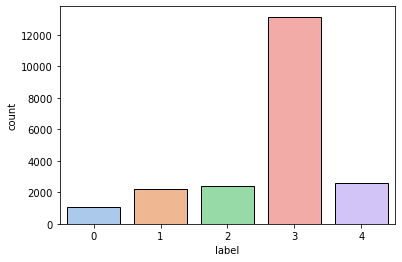

In [4]:
sns.countplot(train_labels.label, edgecolor = 'black',
              palette = sns.color_palette("pastel", 5))
plt.show()

In [5]:
sample = train_labels[train_labels.label == 3].sample(1)
image = cv2.imread(os.path.join(WORK_DIR, "train_images", sample.iloc[0,0]))
print(image.shape)

(600, 800, 3)


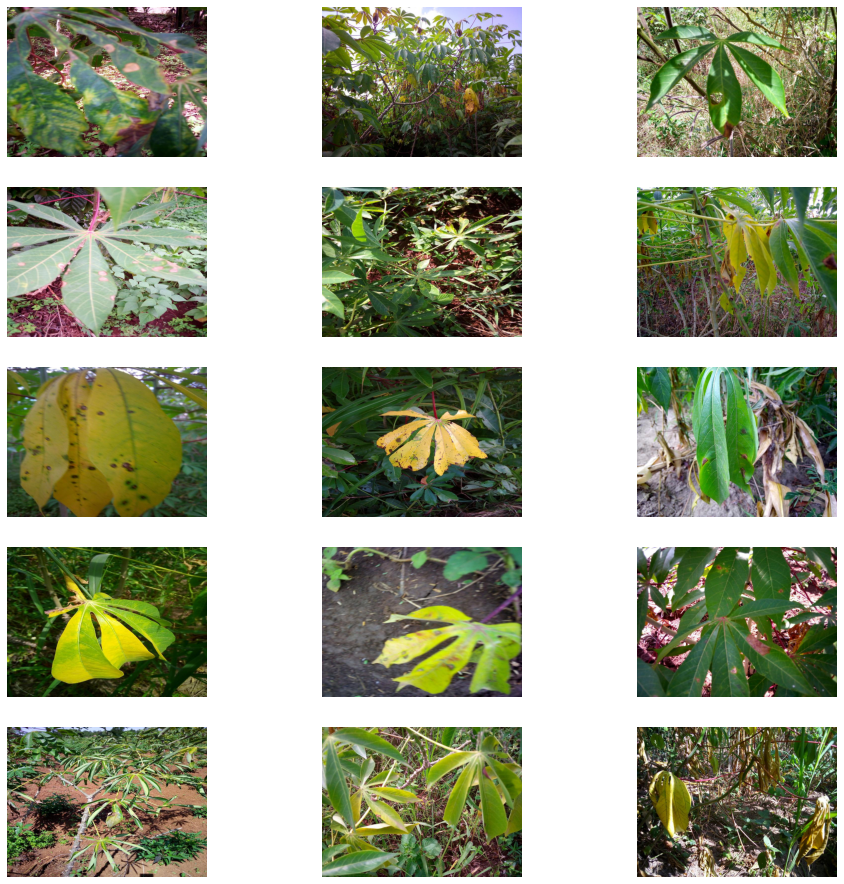

In [6]:
sample = train_labels[train_labels.label == 0].sample(15)
plt.figure(figsize=(16, 16))
for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(5, 3, ind + 1)
    image = cv2.imread(os.path.join(WORK_DIR, "train_images", image_id))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")
    
plt.show()

In [7]:
BATCH_SIZE = 32
STEPS_PER_EPOCH = len(train_labels)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train_labels)*0.2 / BATCH_SIZE
EPOCHS = 10
TARGET_SIZE = 224

train_labels.label = train_labels.label.astype('str')

train_gen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     zoom_range = 0.2,
                                     cval = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.2,
                                     height_shift_range = 0.2,
                                     width_shift_range = 0.2, 
                                     rescale=1.0/255.0) 

valid_gen = ImageDataGenerator(validation_split=0.2, rescale=1.0/255.0) 

train_it = train_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")

valid_it = valid_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")

Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [13]:
class BottleNeck(tf.keras.layers.Layer):
    def __init__(self, filter_num, stride=1):
        super(BottleNeck, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(filters=filter_num,
                                            kernel_size=(1, 1),
                                            strides=1,
                                            padding='same')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.conv2 = tf.keras.layers.Conv2D(filters=filter_num,
                                            kernel_size=(3, 3),
                                            strides=stride,
                                            padding='same')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.conv3 = tf.keras.layers.Conv2D(filters=filter_num * 4,
                                            kernel_size=(1, 1),
                                            strides=1,
                                            padding='same')
        self.bn3 = tf.keras.layers.BatchNormalization()

        self.downsample = tf.keras.Sequential()
        self.downsample.add(tf.keras.layers.Conv2D(filters=filter_num * 4,
                                                   kernel_size=(1, 1),
                                                   strides=stride))
        self.downsample.add(tf.keras.layers.BatchNormalization())

    def call(self, inputs, training=None, **kwargs):
        residual = self.downsample(inputs)

        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = tf.nn.relu(x)
        x = self.conv3(x)
        x = self.bn3(x, training=training)

        output = tf.nn.relu(tf.keras.layers.add([residual, x]))

        return output

def create_model():
        
    
    #base_model = tf.keras.applications.MobileNetV2(input_shape = (224, 224, 3), include_top = False, weights = "imagenet")
    
    base_model=tf.keras.applications.DenseNet201(include_top=False,weights='imagenet',input_shape=(224, 224, 3))
 
    
    
    
    DROP=tf.keras.layers.Dropout(0.2)
    
    filter_num=64
    
    #BTNK=BottleNeck(filter_num=64)
    conv1 = tf.keras.layers.Conv2D(filters=filter_num,
                                            kernel_size=(3, 3),
                                            strides=1,
                                            padding='same')
    bn1 = tf.keras.layers.BatchNormalization()
   
 
    relu= tf.keras.layers.Activation("relu")
       
    Flat=tf.keras.layers.Flatten() 
                  
    prediction_layer = tf.keras.layers.Dense(5, activation='softmax')
    
    
    model = tf.keras.Sequential([base_model,DROP,conv1,bn1,relu,Flat,prediction_layer])
    
    #model = tf.keras.Sequential([base_model,DROP,BTNK,Flat,prediction_layer])
    opt = Adam(lr = 0.0001)
    

    
    model.compile(optimizer = opt ,
                  loss = "sparse_categorical_crossentropy",
                  metrics = ["acc"], 
                  weighted_metrics=["accuracy"]
                 )
    return model



model = create_model()
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet201 (Functional)     (None, 7, 7, 1920)        18321984  
_________________________________________________________________
dropout_4 (Dropout)          (None, 7, 7, 1920)        0         
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 7, 7, 64)          1105984   
_________________________________________________________________
batch_normalization_12 (Batc (None, 7, 7, 64)          256       
_________________________________________________________________
activation_4 (Activation)    (None, 7, 7, 64)          0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 3136)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 5)                

In [14]:
class_weights = class_weight.compute_class_weight('balanced',
                                                 np.unique(train_labels.label),
                                                 train_labels.label)


labels = []

for i in range(len(np.unique(train_labels.label))):
    labels.append(i)
    
    

dict_class_weights = dict(zip(labels, class_weights.tolist())) 


history = model.fit_generator(
    train_it,
    steps_per_epoch = STEPS_PER_EPOCH,
    epochs = EPOCHS,
    validation_data = valid_it,
    validation_steps = VALIDATION_STEPS,
    class_weight=dict_class_weights
)

Epoch 1/10
534/534 [==============================] - 476s 859ms/step - loss: 1.2886 - acc: 0.5200 - accuracy: 0.4702 - val_loss: 0.8104 - val_acc: 0.7041 - val_accuracy: 0.7041
Epoch 2/10
534/534 [==============================] - 389s 726ms/step - loss: 0.8194 - acc: 0.7196 - accuracy: 0.6914 - val_loss: 0.7264 - val_acc: 0.7441 - val_accuracy: 0.7441
Epoch 3/10
534/534 [==============================] - 389s 727ms/step - loss: 0.6966 - acc: 0.7772 - accuracy: 0.7420 - val_loss: 0.6261 - val_acc: 0.7815 - val_accuracy: 0.7815
Epoch 4/10
534/534 [==============================] - 389s 726ms/step - loss: 0.6522 - acc: 0.7947 - accuracy: 0.7571 - val_loss: 0.7611 - val_acc: 0.7268 - val_accuracy: 0.7268
Epoch 5/10
534/534 [==============================] - 389s 728ms/step - loss: 0.6287 - acc: 0.7938 - accuracy: 0.7721 - val_loss: 0.6578 - val_acc: 0.7787 - val_accuracy: 0.7787
Epoch 6/10
534/534 [==============================] - 389s 728ms/step - loss: 0.5619 - acc: 0.8223 - accuracy:

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_style("white")
plt.suptitle('Train history', size = 15)

ax1.plot(epochs, acc, "bo", label = "Training acc")
ax1.plot(epochs, val_acc, "b", label = "Validation acc")
ax1.set_title("Training and validation acc")
ax1.legend()

ax2.plot(epochs, loss, "bo", label = "Training loss", color = 'red')
ax2.plot(epochs, val_loss, "b", label = "Validation loss", color = 'red')
ax2.set_title("Training and validation loss")
ax2.legend()

plt.show()
model.save('./baseline_model.h5')

In [ ]:
ss = pd.read_csv(os.path.join(WORK_DIR, "sample_submission.csv"))
ss

In [ ]:
preds = []

for image_id in ss.image_id:
    image = Image.open(os.path.join(WORK_DIR,  "test_images", image_id))
    image = image.resize((224, 224))
    image = np.expand_dims(image, axis = 0)
    preds.append(np.argmax(model.predict(image)))

ss['label'] = preds
ss


In [ ]:
ss.to_csv('submission.csv', index = False)

In [ ]:
from shutil import copyfile

# copy our file into the working directory (make sure it has .py suffix)
#copyfile(src = "../input/cassava-leaf-disease-classification/submission.csv", dst = "../working/submission.csv")
#copyfile(src = "../input/axilury/ops.py", dst = "../working//axilury/ops.py")